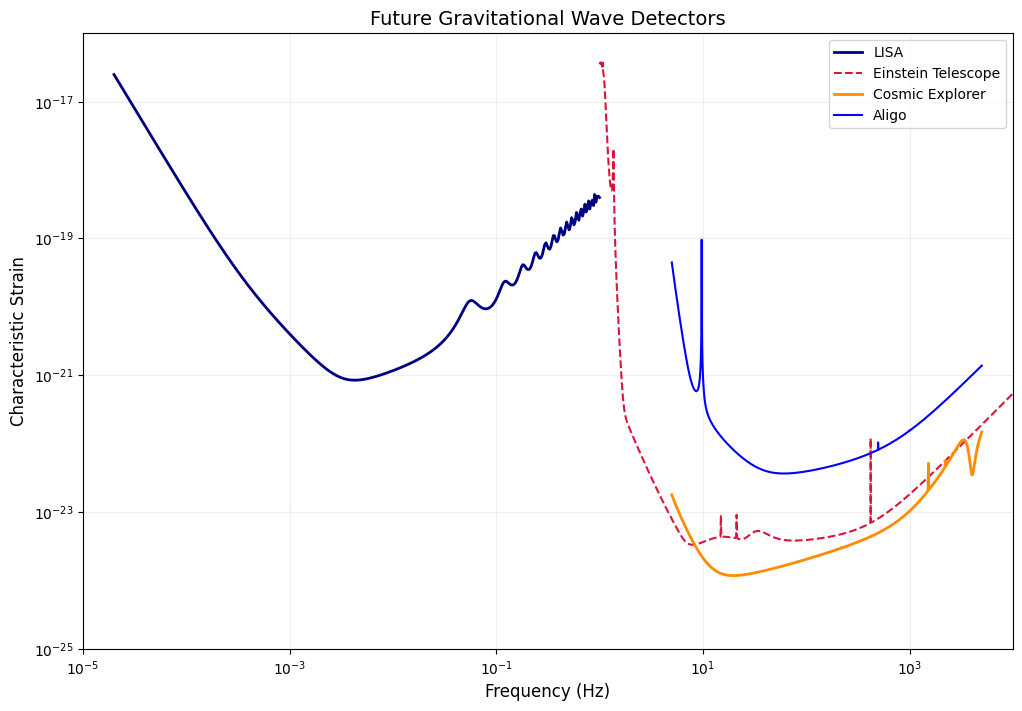

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definição dos caminhos
path_lisa = 'lisa_curves/lisa_strain.txt'
path_et   = 'et_curves/et_d.txt'
path_ce   = 'ce_curves/ce_sensitivity/cosmic_explorer_strain.txt'
path_ligo = 'et_curves/aligo.txt'

plt.figure(figsize=(12, 8))

# --- PLOT LISA ---
data_lisa = np.loadtxt(path_lisa)
f_lisa = data_lisa[:, 0]
hc_lisa = np.sqrt( data_lisa[:, 1] * (f_lisa)) 
plt.loglog(f_lisa, hc_lisa, label='LISA', color='navy', lw=2)

# --- PLOT EINSTEIN TELESCOPE ---
data_et = np.loadtxt(path_et)
f_et = data_et[:, 0]
asd_et = data_et[:, 1] if data_et.shape[1] > 3 else data_et[:, 1]
plt.loglog(f_et, asd_et * np.sqrt(f_et), label='Einstein Telescope', color='crimson', ls='--')
plt.xlim(1e-1, 1e4)

# --- PLOT COSMIC EXPLORER ---
data_ce = np.loadtxt(path_ce)
f_ce = data_ce[:, 0]
asd_ce = data_ce[:, 1]
plt.loglog(f_ce, asd_ce * np.sqrt(f_ce), label='Cosmic Explorer', color='darkorange', lw=2)

# --- PLOT ADVANCED LIGO ----
data_ligo = np.loadtxt(path_ligo)
f_ligo = data_ligo[:, 0]
asd_ligo = data_ligo[:, 1]
plt.loglog(f_ligo, asd_ligo*np.sqrt(f_ligo), label='Aligo', color ='blue') 

# Estilização
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Characteristic Strain', fontsize=12)
plt.title('Future Gravitational Wave Detectors', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.xlim(1e-5, 1e4)
plt.ylim(1e-25, 1e-16)

plt.show()


<>:64: SyntaxWarning: invalid escape sequence '\o'
<>:64: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_889/2620187696.py:64: SyntaxWarning: invalid escape sequence '\o'
  label=f'Signal {m1+m2}$M_\odot$ (z=0.5)',
/home/andrecaire/maggiore_waveforms/.venv/lib/python3.12/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1
/home/andrecaire/maggiore_

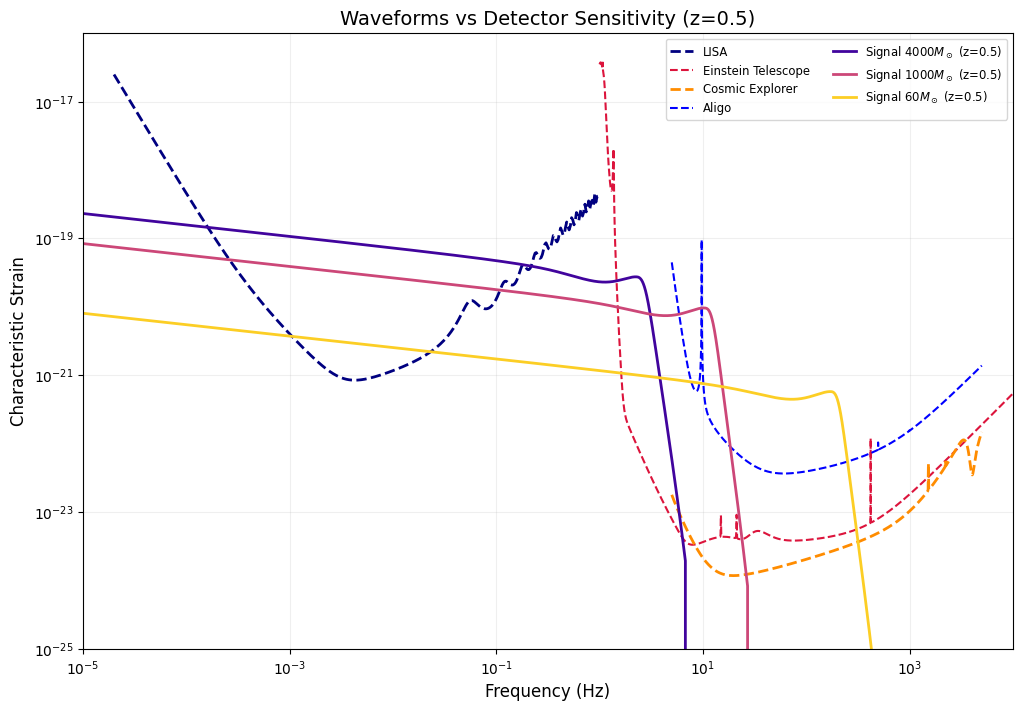

In [ ]:
from pycbc.waveform import get_fd_waveform
import numpy as np
import matplotlib.pyplot as plt

# Definição dos caminhos
path_lisa = 'lisa_curves/lisa_strain.txt'
path_et   = 'et_curves/et_d.txt'
path_ce   = 'ce_curves/ce_sensitivity/cosmic_explorer_strain.txt'
path_ligo = 'et_curves/aligo.txt'

# --- CONFIGURAÇÕES COSMOLÓGICAS (z=0.5) ---
z = 0.5
dist_l = 2800  # Mpc para z=0.5
mass_pairs = [(3000, 1000), (500, 500), (30, 30)]

plt.figure(figsize=(12, 8))

# --- PLOT LISA ---
data_lisa = np.loadtxt(path_lisa)
f_lisa = data_lisa[:, 0]
hc_lisa = np.sqrt(data_lisa[:, 1] * f_lisa) 
plt.loglog(f_lisa, hc_lisa, label='LISA', color='navy', lw=2, ls='--')

# --- PLOT EINSTEIN TELESCOPE ---
data_et = np.loadtxt(path_et)
f_et = data_et[:, 0]
# Correção de índice: usando a coluna 1 para ASD
asd_et = data_et[:, 1] 
plt.loglog(f_et, asd_et * np.sqrt(f_et), label='Einstein Telescope', color='crimson', ls='--')

# --- PLOT COSMIC EXPLORER ---
data_ce = np.loadtxt(path_ce)
f_ce = data_ce[:, 0]
asd_ce = data_ce[:, 1]
plt.loglog(f_ce, asd_ce * np.sqrt(f_ce), label='Cosmic Explorer', color='darkorange', lw=2, ls='--')

# --- PLOT ADVANCED LIGO (Correção da Sintaxe aqui) ---
data_ligo = np.loadtxt(path_ligo)
f_ligo = data_ligo[:, 0]
asd_ligo = data_ligo[:, 1]
plt.loglog(f_ligo, asd_ligo*np.sqrt(f_ligo), label='Aligo', color='blue', ls='--') 

# --- 2. PLOT DAS WAVEFORMS (PyCBC) ---

# 'viridis', 'plasma' ou 'inferno' são ótimas escolhas
cmap = plt.get_cmap('plasma') 
colors = cmap(np.linspace(0.1, 0.9, len(mass_pairs))) 

# 2. Use o enumerate para acessar a cor pelo índice 'i'
for i, (m1, m2) in enumerate(mass_pairs):
    m1_det = m1 * (1 + z) 
    m2_det = m2 * (1 + z)
    
    hp, _ = get_fd_waveform(approximant="IMRPhenomD",
                             mass1=m1_det, mass2=m2_det,
                             f_lower=1e-3, 
                             delta_f=1e-5, 
                             distance=dist_l)
    
    hc_wave = 2 * np.abs(hp) * hp.sample_frequencies 
    
    # 3. Adicione o argumento 'color=colors[i]' aqui:
    plt.loglog(hp.sample_frequencies, hc_wave, 
               label=f'Signal {m1+m2}$M_\odot$ (z=0.5)', 
               lw=2, 
               color=colors[i])
    
# --- ESTILIZAÇÃO FINAL ---
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Characteristic Strain', fontsize=12)
plt.title('Waveforms vs Detector Sensitivity (z=0.5)', fontsize=14)
plt.legend(ncol=2, fontsize='small')
plt.grid(True, which="major", alpha=0.2)
plt.xlim(1e-5, 1e4)
plt.ylim(1e-25, 1e-16)

plt.show()



<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_1245/2146804693.py:33: SyntaxWarning: invalid escape sequence '\o'
  plt.loglog(hp.sample_frequencies, hc, label=f'Total Mass: {m1+m2} $M_\odot$ (z=0.5)')


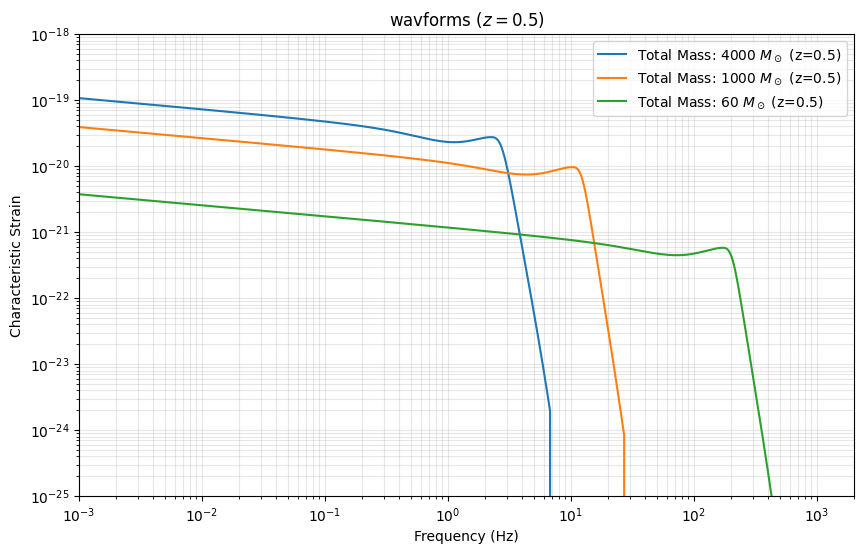

In [3]:
from pycbc.waveform import get_fd_waveform
import matplotlib.pyplot as plt
import numpy as np


z = 0.5
dist_l = 2800 


mass_pairs = [
    (3000, 1000), # Pop-A
    (500, 500),   # Pop-B
    (30, 30)      # Pop-C
]

plt.figure(figsize=(10, 6))

for m1, m2 in mass_pairs:
    m1_det = m1 * (1 + z)
    m2_det = m2 * (1 + z)
    
    # Gerando a Waveform no domínio da frequência
    hp, _ = get_fd_waveform(approximant="IMRPhenomD",
                             mass1=m1_det, 
                             mass2=m2_det,
                             f_lower=1e-3, 
                             delta_f=1e-4,
                             distance=dist_l)
    
    # Calculando o Characteristic Strain: hc = 2 * |h(f)| * f
    hc = 2 * np.abs(hp) * hp.sample_frequencies
    
    plt.loglog(hp.sample_frequencies, hc, label=f'Total Mass: {m1+m2} $M_\odot$ (z=0.5)')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Characteristic Strain')
plt.title('wavforms ($z=0.5$)')
plt.xlim(1e-3, 2000) 
plt.ylim(1e-25, 1e-18) 

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, integrate, interpolate
from matplotlib.lines import Line2D
import warnings

# Ignorar avisos
warnings.filterwarnings('ignore')

# --- CONSTANTES E SETUP ---
CLIGHT=3.e8
MTSUN_SEC=5.e-6
MRSUN_M=1.5e3
PC_M=3.086e16
YEAR=np.pi*1.e7
EPS=1.e-5

import os

# Define o caminho para a pasta do NANOGrav que você acabou de baixar
nanograv_path = "NANOGrav15yr_KDE-FreeSpectra_v1.0.0/30f_fs{hd+mp+dp+cp}_ceffyl_hd-only"

# Tenta carregar as frequências do local específico
try:
    # Tenta no diretório atual, depois no diretório específico do NANOGrav
    if os.path.exists("freqs.npy"):
        FREQS = np.load("freqs.npy")
        print(f"Sucesso: 'freqs.npy' carregado localmente. ({len(FREQS)} frequências)")
    else:
        # Tenta carregar de dentro da pasta do NANOGrav
        full_path = os.path.join(nanograv_path, "freqs.npy")
        FREQS = np.load(full_path)
        print(f"Sucesso: Frequências carregadas do NANOGrav 15yr. ({len(FREQS)} frequências)")
except Exception as e:
    print(f"AVISO: Não foi possível carregar freqs.npy ({e}). Usando frequências sintéticas.")
    FREQS = np.logspace(np.log10(1.9e-9), np.log10(5e-8), 30)
    
FMIN=FREQS[0]
TOBS=1./FREQS[0]

# --- FUNÇÕES FÍSICAS (COPIADAS DO UTIL) ---
def window(ll,frac=0.01):
    return signal.windows.tukey(ll,frac)

def f_isco(M):
    return 1./(6.*np.sqrt(6.)*M*MTSUN_SEC)

def dfgw(Mcred,f0):
    return 96./5.*pow(np.pi*Mcred*MTSUN_SEC*f0,5./3.)*np.pi*f0*f0

def fgw_tsec(dtm,Mcred,f0,nu=0.25):
    MTcred53=pow(Mcred*MTSUN_SEC,5./3.)
    Mred=Mcred/pow(nu,0.6)
    pi83=pow(np.pi,8./3.)
    f0m83=pow(f0,-8./3.)
    Dfm83=256./5.*pi83*MTcred53
    if hasattr(dtm, '__len__'):
        if (Dfm83*dtm[min(3,len(dtm)-1)])>f0m83: return np.inf
        elif Dfm83*dtm[-1]>f0m83:
            idx=0
            fisco=f_isco(Mred)
            while True:
                if (idx >= len(dtm)) or (Dfm83*dtm[idx]>f0m83): break
                fi=pow(f0m83-Dfm83*dtm[idx],-0.375)
                if (fi>fisco): break
                else: idx+=1
            return pow(f0m83-Dfm83*dtm[:idx], -0.375)
        else: return pow(f0m83-Dfm83*dtm, -0.375)
    else: return np.inf

def voff(Mred,f):
    return pow(np.pi*f*Mred*MTSUN_SEC,1./3.)

def voft(dtm,Mred,nu,f0):
    Mcred=Mred*pow(nu,0.6)
    return voff(Mred,fgw_tsec(dtm,Mcred,f0))

def phioft(tms,Mcred,f0):
    Mcred53=pow(Mcred*MTSUN_SEC,5./3.)
    pi83=pow(np.pi,8./3.)
    f0m83=1./pow(f0,8./3.)
    sct=256./5.*pi83*Mcred53*tms
    idx=len(sct)-1
    while ( (f0m83<sct[idx])and(idx<len(tms)) and (idx >= 0)): idx-=1
    sct=sct[:idx+1]
    val = f0m83-sct
    val[val < 0] = 0
    return -2.*np.pi/(32.*pi83*Mcred53)*pow(val,0.625)

def t_merger(Mcred,f0):
    return 5./(256.*np.pi*f0)*pow(np.pi*Mcred*MTSUN_SEC*f0,-5./3.)

def hoft(tms,nu,Mred,f0,phi0=0.):
    Mcred=pow(nu,0.6)*Mred
    tmrg=t_merger(Mcred,f0)
    tin=tms
    mergerinband=0
    MINL=64
    if ((tin[-1]>tmrg)and(len(tin)>MINL)):
        lt=len(tin)
        tin=tin[0:int(lt/2)]
        if len(tin)<=MINL: mergerinband=1
   
    if mergerinband: return np.zeros(len(tms)), tms
   
    v=voft(tin,Mred,nu,f0)
    if np.any(np.isinf(v)): return np.zeros(len(tms)), tms

    phase=phioft(tin,Mcred,f0)
    L=min(len(v),len(phase))
    return 4.*nu*Mred*MTSUN_SEC*v[:L]*v[:L]*np.cos(phase[:L]+phi0), tin[:L]

def hoffN(freqs,f0,Mred,nu,T=TOBS,t0=0.,NPTSt=4096):
    if hasattr(f0, '__len__'): return -1
    tms=np.linspace(0.,T,NPTSt)
    ht, tmss=hoft(tms,nu,Mred,f0)
   
    if len(ht) > 0:
        dt=tmss[1]-tmss[0]
        f_fft=np.fft.rfftfreq(len(tmss),dt)
        hoff=np.fft.rfft(window(len(tmss))*ht)
        hoff*=dt*np.exp(2.j*np.pi*f_fft*t0)
        php_int=interpolate.interp1d(f_fft,np.unwrap(np.angle(hoff)),bounds_error=False,fill_value=0.)
        amp_int=interpolate.interp1d(f_fft,np.abs(hoff),bounds_error=False,fill_value=0.)
        return amp_int(freqs)*np.exp(1.j*php_int(freqs))*CLIGHT
    else: return np.zeros(len(freqs))

def ihoff(freqs,f0s,Mred,nu,T=TOBS,fpivot=1./TOBS,a=0.,t0=0.,hfunc=hoffN):
    nf0=len(f0s)
    f0prior=pow(fpivot/f0s,a)/f0s
    nf=len(freqs)
    store=np.zeros((nf,nf0))
   
    for idx in range(nf0):
        f0=f0s[idx]
        tmp=np.abs(hfunc(freqs,f0,Mred,nu,T,t0))
        store[:,idx]=tmp
           
    out=np.zeros(nf)
    for idx in range(nf):
        integrand=interpolate.interp1d(f0s,store[idx,:]*store[idx,:]*f0prior,bounds_error=False,fill_value=0.)
        y,err=integrate.quad(integrand,f0s[0],f0s[-1], limit=100) # Limit ajustado
        out[idx]=y
    return out

print("Funções carregadas com sucesso!")

Sucesso: Frequências carregadas do NANOGrav 15yr. (30 frequências)
Funções carregadas com sucesso!


In [ ]:
print("--- Iniciando Cálculo (NG0 conforme o texto) ---")

# --- PARÂMETROS ---
f0s = pow(10., np.linspace(np.log10(0.9*FREQS[0]), np.log10(1.1*FREQS[-1]), 30))

# Mantendo 50 pontos para as curvas ficarem lisas (sem serrilhado)
Ms = pow(10., np.linspace(6.5, 11, 50))

nu = 0.25
z = 0.

NG0 = 1.e-63

aas = [0., 1., 2.]
bs = [-1., 0., 1.]
colors = ['red', 'green', 'orange']
res = np.zeros((len(aas), len(bs), len(FREQS)))

# Loop Principal
for idxa, a in enumerate(aas):
    print(f"Calculando Alpha {a} ({colors[idxa]})...")
    hint_matrix = np.zeros((len(Ms), len(FREQS)))
   
    # 1. Calcula Matriz de Massas
    for idxM, M in enumerate(Ms):
        Mred = M*(1.+z)
        hint_matrix[idxM, :] = ihoff(FREQS, f0s, Mred, nu, TOBS, 1./TOBS, a, 0., hoffN)
   
    # 2. Integra sobre Betas
    for idxb, b in enumerate(bs):
        for idxf in range(len(FREQS)):
            y_vals = hint_matrix[:, idxf]/Ms * pow(Ms[0]/Ms, b)
            result = integrate.trapezoid(y_vals, Ms)
            res[idxa, idxb, idxf] = NG0 * 32. * np.pi/5. * FREQS[idxf] * result

print("Cálculo finalizado com NG0 = 1.e-63")

--- Iniciando Cálculo (NG0 conforme o texto) ---
Calculando Alpha 0.0 (red)...
Calculando Alpha 1.0 (green)...
Calculando Alpha 2.0 (orange)...
Cálculo finalizado com NG0 = 1.e-63


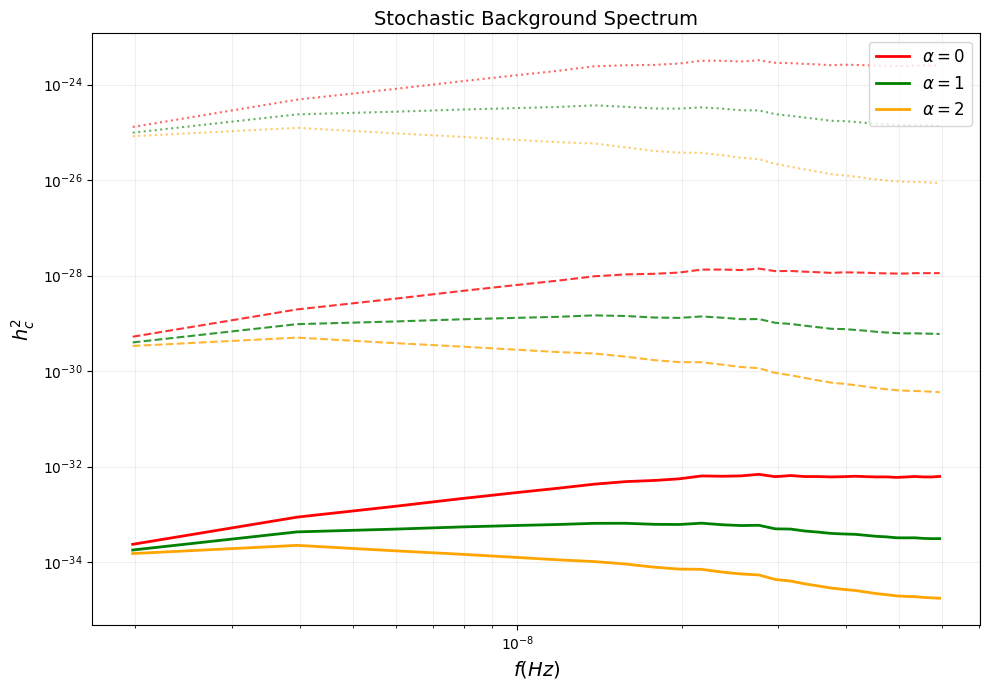

In [10]:
plt.figure(figsize=(10, 7))

for idxa, a in enumerate(aas):
    for idxb, b in enumerate(bs):
        if b == 1: ls, lw, al = '-', 2, 1.0    
        elif b == 0: ls, lw, al = '--', 1.5, 0.8
        else: ls, lw, al = ':', 1.5, 0.6        
           
        plt.loglog(FREQS, res[idxa, idxb, :], color=colors[idxa], linestyle=ls, linewidth=lw, alpha=al)

plt.ylabel(r"$h_c^2$", fontsize=14)
plt.xlabel(r"$f(Hz)$", fontsize=14)
plt.title(r"Stochastic Background Spectrum", fontsize=14)
plt.grid(True, which="both", alpha=0.2)

# LEGENDA APENAS ALPHAS
legend_elements = [
    Line2D([0], [0], color='red', lw=2, label=r'$\alpha=0$'),
    Line2D([0], [0], color='green', lw=2, label=r'$\alpha=1$'),
    Line2D([0], [0], color='orange', lw=2, label=r'$\alpha=2$')
]

plt.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=12)
plt.tight_layout()
plt.show()

<>:62: SyntaxWarning: invalid escape sequence '\o'
<>:62: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_1462/3839320686.py:62: SyntaxWarning: invalid escape sequence '\o'
  label=f'Signal {m1+m2}$M_\odot$ ($f_{{start}}$={f_min_indiv}Hz)')
/home/andrecaire/maggiore_waveforms/.venv/lib/python3.12/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1
/

NameError: name 'res' is not defined

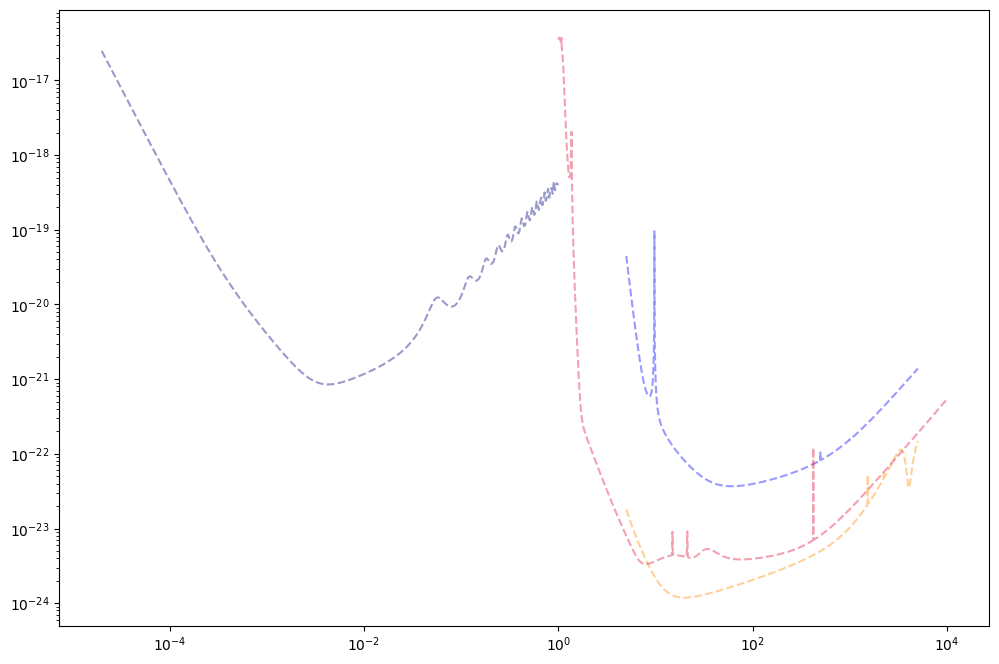

In [1]:
from pycbc.waveform import get_fd_waveform
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- DATA PATH ---
path_lisa = 'lisa_curves/lisa_strain.txt'
path_et   = 'et_curves/et_d.txt'
path_ce   = 'ce_curves/ce_sensitivity/cosmic_explorer_strain.txt'
path_ligo = 'et_curves/aligo.txt'

z, dist_l = 0.5, 2800
mass_pairs = [(3000, 1000), (500, 500), (30, 30)]

plt.figure(figsize=(12, 8))

# --- 1. DETCTOR SENSITIVITY ---
for path, label, col in [(path_lisa, 'LISA', 'navy'), (path_ce, 'Cosmic Explorer', 'darkorange'), (path_ligo, 'aLIGO', 'blue')]:
    data = np.loadtxt(path)
    plt.loglog(data[:, 0], np.sqrt(data[:, 1] * data[:, 0]) if 'lisa' in path else data[:, 1] * np.sqrt(data[:, 0]), 
               label=label, color=col, lw=1.5, ls='--', alpha=0.4)

data_et = np.loadtxt(path_et)
plt.loglog(data_et[:, 0], data_et[:, 1] * np.sqrt(data_et[:, 0]), label='Einstein Telescope', color='crimson', ls='--', alpha=0.4)

# --- 2. SGWB MODEL BY RICCARDO AND ANDRE (Alpha=1, Beta=0) ---

hc_nanograv = np.sqrt(res[1, 1, :]) 

plt.loglog(FREQS, hc_nanograv, color='forestgreen', lw=3, 
           label=r'SGWB NANOGrav ($\alpha=1, \beta=0$)', alpha=0.9)

f_min_plot = 1e-3  

# --- 3. Masses and intial frequencies (f_min) ---
# (m1, m2, f_inicial)
mass_pairs = [
    (3000, 1000, 1e-3),  # Supermassivo: começa cedo no LISA
    (1200, 80,   1e-2),  # Intermediário
    (100, 20,     1e-2)    # Estelar: começa apenas perto de 1 Hz
]

# --- 4. Waveforms with individuals f_min ---
for i, (m1, m2, f_min_indiv) in enumerate(mass_pairs):
    m1_det, m2_det = m1 * (1 + z), m2 * (1 + z)
    
    # Waveform code
    hp, _ = get_fd_waveform(approximant="IMRPhenomD", 
                             mass1=m1_det, mass2=m2_det,
                             f_lower=f_min_indiv, 
                             delta_f=1e-4, 
                             distance=dist_l)
    
    freqs_wave = hp.sample_frequencies
    hc_wave = 2 * np.abs(hp) * freqs_wave
    
    # Mask to clean the plot
    mask = freqs_wave >= f_min_indiv
    
    plt.loglog(freqs_wave[mask], hc_wave[mask], 
               color=colors[i], lw=2.5, 
               label=f'Signal {m1+m2}$M_\odot$ ($f_{{start}}$={f_min_indiv}Hz)')
    
# --- 5. Plot configuration ---
subdivisoes = np.arange(2, 10)

# X (Frequêncies)
plt.gca().xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=subdivisoes, numticks=15))

#  Y (Strain) 
plt.gca().yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=subdivisoes, numticks=15))

# Ticks
plt.tick_params(axis='both', which='major', length=10, width=1.5, direction='in', top=True, right=True)
plt.tick_params(axis='both', which='minor', length=5, width=1.0, direction='in', top=True, right=True)

# Grid
plt.grid(True, which="major", alpha=0.4, ls='-', color='gray')    # Grid principal mais forte
plt.grid(True, which="minor", alpha=0.15, ls=':', color='gray')  # Grid secundário (os risquinhos novos)

plt.xlabel('Frequency (Hz)', fontsize=13)
plt.ylabel('Characteristic Strain ($h_c$)', fontsize=13)
plt.title('GW Landscape: Precise Multi-Band View', fontsize=15)
plt.legend(ncol=2, fontsize='small', frameon=True)

# Limits
plt.xlim(1e-9, 2000) 
plt.ylim(1e-25, 1e-13)

plt.show()

<>:51: SyntaxWarning: invalid escape sequence '\o'
<>:51: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_325610/3999310170.py:51: SyntaxWarning: invalid escape sequence '\o'
  ax2.set_xlabel('Chirp Mass ($M_c$) $[M_\odot]$')


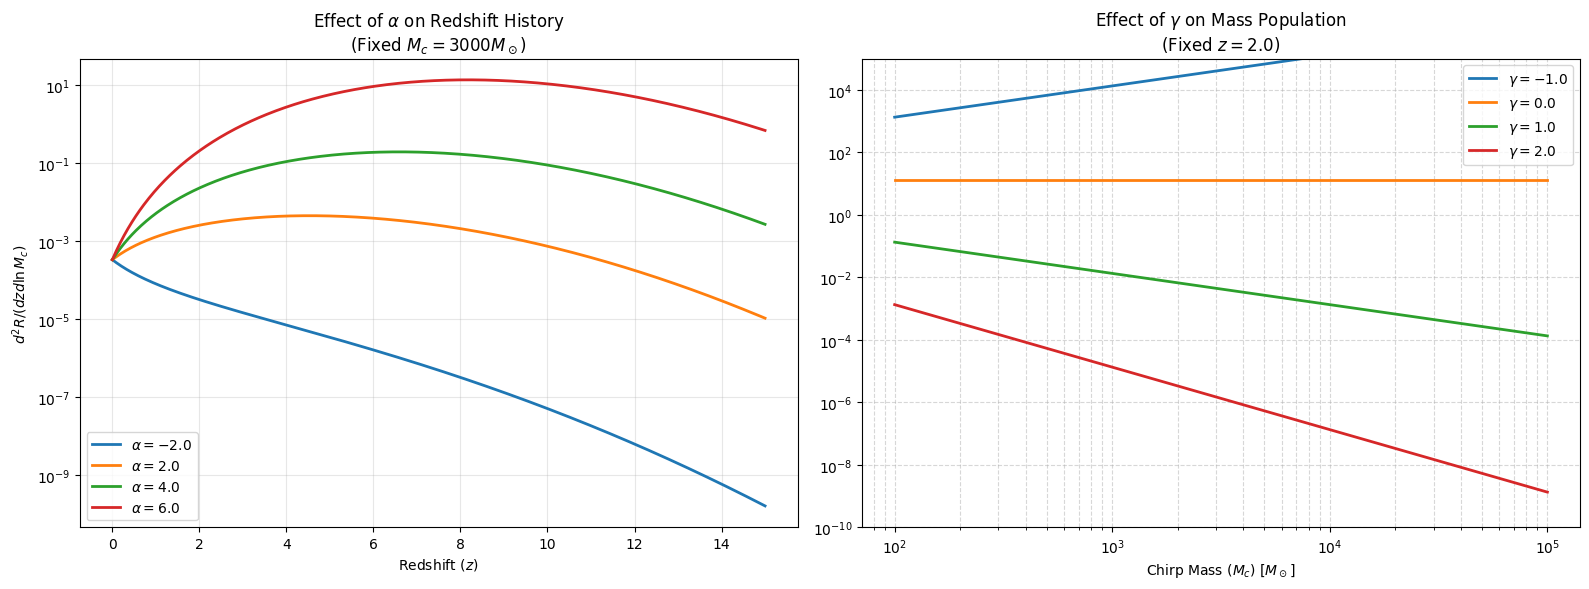

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Toy Model Definition ---
def merger_rate(z, Mc, R0, alpha, beta, z0, gamma, M_max, M_star):
    # Time/Redshift evolution: dR/dz
    term_z = (1 + z)**alpha * np.exp(- (z / z0)**beta)
    # Mass distribution: dR/dlnMc
    term_M = (Mc / M_star)**(-gamma) * np.exp(- Mc / M_max)
    return R0 * term_z * term_M

# --- 2. Fixed Parameters for IMBH Study ---
z_arr = np.linspace(0, 15, 500)
Mc_arr = np.logspace(2, 5, 500)  # Mass range from 100 to 100,000 M_sun
R0_fix = 1.0                    # Standard local rate
z0_fix = 5.0                    # Peak redshift
beta_fix = 2.0                  # Shape of the peak
M_max_fix = 1e10                 # Mass cutoff
M_star = 1.0                    # Reference mass

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- 3. Testing ALPHA (Effect on Redshift Evolution) ---
# Fix mass to observe the redshift behavior
Mc_test = 3000 
alphas = [-2.0, 2.0, 4.0, 6.0]

for a in alphas:
    rate_z = merger_rate(z_arr, Mc_test, R0_fix, alpha=a, beta=beta_fix, 
                         z0=z0_fix, gamma=1.0, M_max=M_max_fix, M_star=M_star)
    ax1.plot(z_arr, rate_z, label=f'$\\alpha = {a}$', lw=2)

ax1.set_title(f'Effect of $\\alpha$ on Redshift History\n(Fixed $M_c = {Mc_test} M_\\odot$)')
ax1.set_xlabel('Redshift ($z$)')
ax1.set_ylabel(r'$d^2R / (dz d\ln M_c)$')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- 4. Testing GAMMA (Effect on Mass Distribution) ---
# Fix redshift to observe the mass behavior
z_test = 2.0
gammas = [-1.0, 0.0, 1.0, 2.0] # -1 means more heavy BHs, 2 means many more light BHs

for g in gammas:
    rate_M = merger_rate(z_test, Mc_arr, R0_fix, alpha=2.5, beta=beta_fix, 
                         z0=z0_fix, gamma=g, M_max=M_max_fix, M_star=M_star)
    ax2.plot(Mc_arr, rate_M, label=f'$\\gamma = {g}$', lw=2)

ax2.set_title(f'Effect of $\\gamma$ on Mass Population\n(Fixed $z = {z_test}$)')
ax2.set_xlabel('Chirp Mass ($M_c$) $[M_\odot]$')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_ylim(1e-10, 1e5) # Adjusting view for gamma impact
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

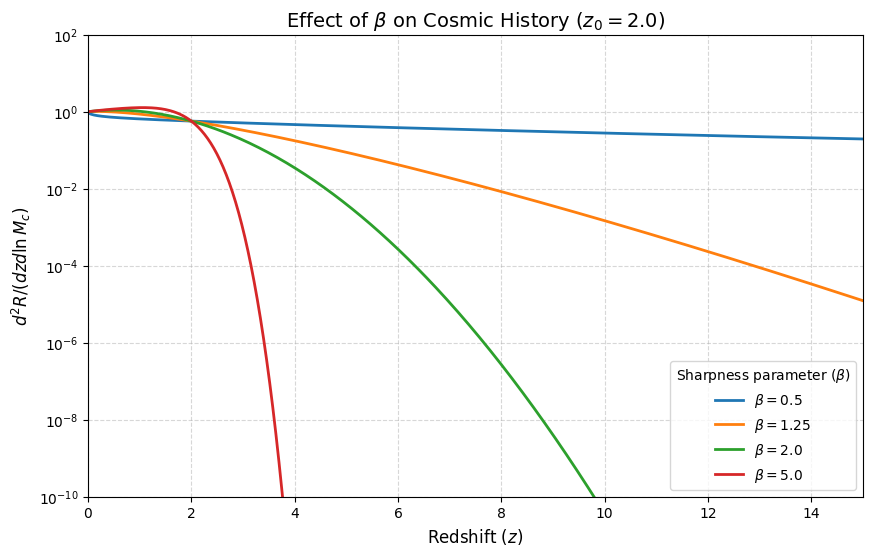

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Toy Model Definition ---
def merger_rate(z, Mc, R0, alpha, beta, z0, gamma, M_max, M_star):
    # term_z contains alpha (growth) and beta (decay/peak sharpness)
    term_z = (1 + z)**alpha * np.exp(- (z / z0)**beta)
    term_M = (Mc / M_star)**(-gamma) * np.exp(- Mc / M_max)
    return R0 * term_z * term_M

# --- 2. Parameters ---
z_arr = np.linspace(0, 15, 500)
Mc_test = 100
R0_fix = 1.0
alpha_fix = 0.4
z0_fix = 2.0
gamma_fix = 0.0
M_max_fix = 1e10
M_star = 1.0

# --- 3. Testing BETA ---
plt.figure(figsize=(10, 6))

# Beta controls the sharpness of the transition after z0
betas = [0.5, 1.25, 2.0, 5.0]

for b in betas:
    rate = merger_rate(z_arr, Mc_test, R0_fix, alpha=alpha_fix, beta=b, 
                       z0=z0_fix, gamma=gamma_fix, M_max=M_max_fix, M_star=M_star)
    plt.plot(z_arr, rate, label=f'$\\beta = {b}$', lw=2)

plt.title(f'Effect of $\\beta$ on Cosmic History ($z_0 = {z0_fix}$)', fontsize=14)
plt.xlabel('Redshift ($z$)', fontsize=12)
plt.ylabel(r'$d^2R / (dz d\ln M_c)$', fontsize=12)
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(title="Sharpness parameter ($\\beta$)")
plt.ylim(1e-10, 1e2) # Limits the Y-axis to a physically meaningful range
plt.xlim(0, 15)      # Keeps the focus on the cosmic history
plt.show()

<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_97542/2585827713.py:36: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('$\log_{10}(M_c / M_{\odot})$')
/tmp/ipykernel_97542/2585827713.py:37: SyntaxWarning: invalid escape sequence '\l'
  ax.set_zlabel('$\log_{10}(Rate)$')
/tmp/ipykernel_97542/2585827713.py:38: SyntaxWarning: invalid escape sequence '\l'
  fig.colorbar(surf, shrink=0.5, aspect=5, label='$\log_{10}$ Rate Density')


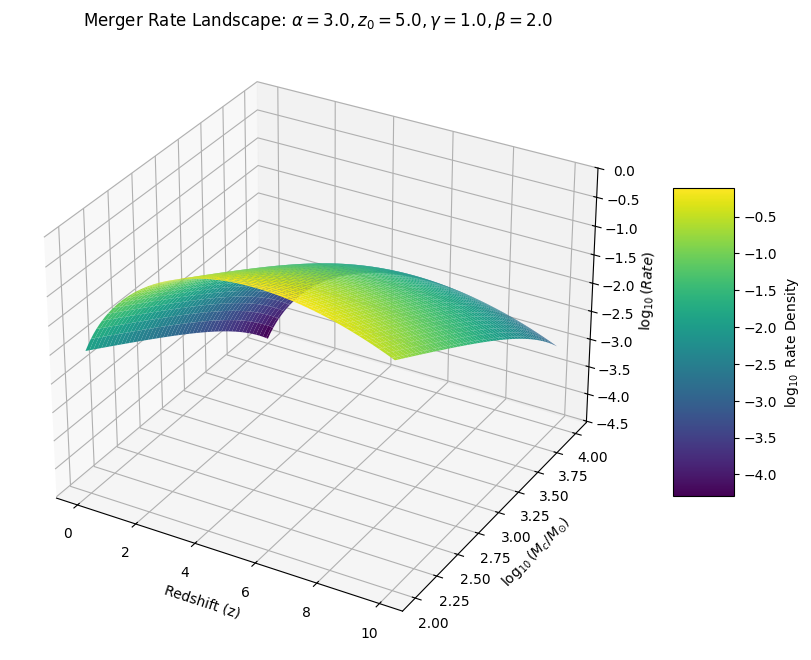

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# --- 1. Toy Model Function ---
def merger_rate(z, Mc, R0, alpha, beta, z0, gamma, M_max, M_star):
    term_z = (1 + z)**alpha * np.exp(- (z / z0)**beta)
    term_M = (Mc / M_star)**(-gamma) * np.exp(- Mc / M_max)
    return R0 * term_z * term_M

# --- 2. Your Parameters ---
R0 = 1.0
alpha = 3.0
z0 = 5.0
gamma = 1.0
beta = 2.0
M_max = 1e4    # Setting to 10,000 for realistic IMBH limit
M_star = 1.0

# --- 3. Grid for 3D Testing ---
z = np.linspace(0, 10, 100)
Mc = np.logspace(2, 4, 100) # 100 to 10,000 M_sun
Z, MC = np.meshgrid(z, Mc)
R = merger_rate(Z, MC, R0, alpha, beta, z0, gamma, M_max, M_star)

# --- 4. Plotting the Rate Surface ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# We plot log10(R) to see the full range of orders of magnitude
surf = ax.plot_surface(Z, np.log10(MC), np.log10(R + 1e-20), cmap=cm.viridis,
                       linewidth=0, antialiased=True)

ax.set_title(f'Merger Rate Landscape: $\\alpha={alpha}, z_0={z0}, \\gamma={gamma}, \\beta={beta}$')
ax.set_xlabel('Redshift (z)')
ax.set_ylabel('$\log_{10}(M_c / M_{\odot})$')
ax.set_zlabel('$\log_{10}(Rate)$')
fig.colorbar(surf, shrink=0.5, aspect=5, label='$\log_{10}$ Rate Density')

plt.show()

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import ceffyl
from ceffyl.Ceffyl import ceffyl as Ceffyl_Analyzer 
from scipy.integrate import dblquad
from scipy.interpolate import interp1d
import time

# --- 1. SETUP & PHYSICS ---
root_path = '/home/andrecaire/maggiore_waveforms/NANOGrav15yr_KDE-FreeSpectra_v1.0.0'
ceffyl_analyzer = Ceffyl_Analyzer(f'{root_path}/30f_fs{{hd}}_ceffyl')

# Constants
G, c, MPC, YEAR = 6.674e-11, 2.998e8, 3.086e22, 3.154e7
M_SOLAR = 1.989e30
H0_SI = 67.4 * 1000 / MPC 
Om, Ol = 0.315, 1.0 - Om

def Hz(z):
    return H0_SI * np.sqrt(Om * (1+z)**3 + Ol)

def d2R_dz_dlnMc(z, Mc, params):
    # params: [R0, alpha, beta, gamma, z0, M_star, M_max]
    R0, alpha, beta, gamma, z0, M_star, M_max = params
    
    # Physics Model
    evol_term = (1+z)**alpha * np.exp(-1.0 * (z/z0)**beta)
    mass_term = (Mc / M_star)**(-gamma) * np.exp(-1.0 * (Mc / M_max))
    
    return R0 * evol_term * mass_term

def get_amplitude_integral(params):
    # Calculates the "Shape" integral (setting R0=1)
    # Returns the value 'A' such that hc^2 = R0 * A * f^(-4/3)
    R0_dummy = 1.0
    mod_params = [R0_dummy] + params[1:] # Use dummy R0
    
    prefactor = (4 * G**(5/3)) / (3 * np.pi**(1/3) * c**2)
    M_max = params[6]
    
    def integrand(Mc, z):
        rate = d2R_dz_dlnMc(z, Mc, mod_params) / ((1000 * MPC)**3 * YEAR)
        physics = ((Mc * M_SOLAR)**(5/3)) / ((1+z)**(1/3) * Hz(z))
        return (rate / Mc) * physics

    # Integrate (Fast tolerance for scanning)
    val, _ = dblquad(integrand, 0, 8, lambda z: 1e2, lambda z: M_max*5, epsabs=0.05, epsrel=0.05)
    return prefactor * val

# --- 2. THE SCANNING PARAMETERS ---

# Fixed constants
FIXED_z0 = 2.0      # Peak redshift
FIXED_Mstar = 1e2   # Characteristic mass (100 million solar masses)
FIXED_Mmax = 1e10   # SMBH Limit (10 billion solar masses)

# ARRAYS TO SCAN (The "Free" Parameters)
# Note: Keep grid sizes small (e.g., 6x6x6) initially to test speed!
alpha_arr = np.linspace(-2, 5, 6)   # Redshift Growth
beta_arr  = np.linspace(0.5, 4, 5)  # Cutoff Sharpness
gamma_arr = np.linspace(0, 2.0, 5)  # Mass Slope

print(f"Grid Size: {len(alpha_arr)}x{len(beta_arr)}x{len(gamma_arr)} = {len(alpha_arr)*len(beta_arr)*len(gamma_arr)} Models")

# Storage
best_lnL = -np.inf
best_params = {}
results = [] # To store (alpha, beta, gamma, best_R0, lnL)

start_t = time.time()

# --- 3. THE LOOP (Corrected) ---
print(f"Starting Scan over {len(alpha_arr)*len(beta_arr)*len(gamma_arr)} models...")

for a in alpha_arr:
    for b in beta_arr:
        for g in gamma_arr:
            
            # 1. Calculate the physics shape
            # params: [R0=1, a, b, g, z0, Mstar, Mmax]
            current_shape_params = [1.0, a, b, g, FIXED_z0, FIXED_Mstar, FIXED_Mmax]
            
            # Integration step
            try:
                amp_factor = get_amplitude_integral(current_shape_params)
            except Exception as e:
                # If integration fails (math error), skip this model
                continue
            
            if amp_factor <= 0: continue
            
            # 2. INNER OPTIMIZER: Find best R0
            # Scan R0 from 10^-12 to 10^-2
            r0_scan = np.logspace(-12, -2, 20) 
            local_best_L = -np.inf
            local_best_R0 = 1e-12
            
            # Base model spectrum (without R0)
            base_hc_sq = amp_factor * ceffyl_analyzer.freqs**(-4/3)
            
            for r0 in r0_scan:
                hc_sq = r0 * base_hc_sq
                hc = np.sqrt(np.maximum(hc_sq, 1e-40))
                model_log_hc = np.log10(hc)
                
                ln_L = 0
                
                # --- FIX STARTS HERE ---
                for k in range(len(ceffyl_analyzer.freqs)):
                    
                    # A. Handle Rho Grid Shape (The Source of your Error)
                    if ceffyl_analyzer.rho_grid.ndim == 2:
                        # If grid is specific to each freq, pick row k
                        current_grid = ceffyl_analyzer.rho_grid[k]
                    else:
                        # If grid is shared/1D, use it as is
                        current_grid = ceffyl_analyzer.rho_grid

                    # B. Handle Density Shape
                    densities = ceffyl_analyzer.density
                    if densities.ndim == 3: densities = densities[0] # remove chain dim
                    if densities.shape[0] != len(ceffyl_analyzer.freqs): densities = densities.T
                    
                    pdf = densities[k]
                    
                    # Normalize PDF
                    pdf = np.maximum(np.nan_to_num(pdf, nan=0.0), 0.0)
                    if np.sum(pdf) > 0: pdf /= np.sum(pdf)
                    
                    # Log Probability
                    log_pdf = np.log(pdf + 1e-100)
                    
                    # Interpolate using the CORRECT grid for this frequency
                    val = np.interp(model_log_hc[k], current_grid, log_pdf, left=-np.inf, right=-np.inf)
                    
                    ln_L += val
                # --- FIX ENDS HERE ---
                
                if ln_L > local_best_L:
                    local_best_L = ln_L
                    local_best_R0 = r0
            
            # Store Result
            if local_best_L > -6000: # Only save "reasonable" fits to save memory
                 results.append((a, b, g, local_best_R0, local_best_L))
            
            # Check for new global winner
            if local_best_L > best_lnL:
                best_lnL = local_best_L
                best_params = {'alpha': a, 'beta': b, 'gamma': g, 'R0': local_best_R0}
                print(f"New Best! L={best_lnL:.1f} | a={a:.1f}, b={b:.1f}, g={g:.1f}, R0={local_best_R0:.1e}")

print(f"\n--- SCAN COMPLETE in {time.time()-start_t:.1f}s ---")
print("BEST PARAMETERS FOUND:")
print(f"Alpha (Growth): {best_params.get('alpha')}")
print(f"Beta (Cutoff):  {best_params.get('beta')}")
print(f"Gamma (Slope):  {best_params.get('gamma')}")
print(f"R0 (Rate):      {best_params.get('R0')}")

Grid Size: 6x5x5 = 150 Models
Starting Scan over 150 models...
New Best! L=-6907.8 | a=-2.0, b=0.5, g=0.0, R0=1.8e-07

--- SCAN COMPLETE in 10.0s ---
BEST PARAMETERS FOUND:
Alpha (Growth): -2.0
Beta (Cutoff):  0.5
Gamma (Slope):  0.0
R0 (Rate):      1.8329807108324338e-07


In [1]:
import numpy as np
import ceffyl
from ceffyl.Ceffyl import ceffyl as Ceffyl_Analyzer 
from scipy.integrate import dblquad
import time

# --- 1. SETUP & PHYSICS ---
# Ensure this path points to your actual data folder
root_path = '/home/andrecaire/maggiore_waveforms/NANOGrav15yr_KDE-FreeSpectra_v1.0.0'
try:
    ceffyl_analyzer = Ceffyl_Analyzer(f'{root_path}/30f_fs{{hd}}_ceffyl')
    print(f"Loaded Ceffyl Data: {len(ceffyl_analyzer.freqs)} frequency bins.")
except Exception as e:
    print(f"Error loading Ceffyl: {e}")
    # Fallback for testing if files are missing (Comment this out in production)
    # raise SystemExit 

# Constants
G, c, MPC, YEAR = 6.674e-11, 2.998e8, 3.086e22, 3.154e7
M_SOLAR = 1.989e30
H0_SI = 67.4 * 1000 / MPC 
Om, Ol = 0.315, 1.0 - 0.315

def Hz(z):
    return H0_SI * np.sqrt(Om * (1+z)**3 + Ol)

def d2R_dz_dlnMc(z, Mc, params):
    # params: [R0, alpha, beta, gamma, z0, M_star, M_max]
    R0, alpha, beta, gamma, z0, M_star, M_max = params
    
    # Physics Model
    evol_term = (1+z)**alpha * np.exp(-1.0 * (z/z0)**beta)
    mass_term = (Mc / M_star)**(-gamma) * np.exp(-1.0 * (Mc / M_max))
    
    return R0 * evol_term * mass_term

def get_amplitude_integral(params):
    # Calculates the "Shape" integral (setting R0=1)
    # Returns 'A' such that hc^2 = R0 * A * f^(-4/3)
    R0_dummy = 1.0
    mod_params = [R0_dummy] + params[1:] 
    
    prefactor = (4 * G**(5/3)) / (3 * np.pi**(1/3) * c**2)
    M_max = params[6]
    M_star = params[5]
    
    def integrand(Mc, z):
        rate = d2R_dz_dlnMc(z, Mc, mod_params) / ((1000 * MPC)**3 * YEAR)
        physics = ((Mc * M_SOLAR)**(5/3)) / ((1+z)**(1/3) * Hz(z))
        return (rate / Mc) * physics

    # Integrate 
    # Note: Limits set for Pop III (0->10 redshift, M_star->M_max)
    val, _ = dblquad(integrand, 0, 10, lambda z: M_star, lambda z: M_max*5, epsabs=0.05, epsrel=0.05)
    return prefactor * val

# --- 2. THE SCANNING PARAMETERS ---

# Fixed constants for Pop III seeds
FIXED_z0 = 2.0      
FIXED_Mstar = 10e10  # 100 Solar Masses
FIXED_Mmax = 1e11   # SMBH Limit

# ARRAYS TO SCAN
alpha_arr = np.linspace(-2, 4, 6)   # Redshift Growth
beta_arr  = np.linspace(0.5, 3, 5)  # Cutoff Sharpness
gamma_arr = np.linspace(0, 2.0, 5)  # Mass Slope

# "Mature" R0 Scan: High resolution, wide range
r0_scan = np.logspace(-12, -2, 50) 

total_models = len(alpha_arr)*len(beta_arr)*len(gamma_arr)
print(f"Grid: {len(alpha_arr)}x{len(beta_arr)}x{len(gamma_arr)} Shapes x {len(r0_scan)} Rates")
print(f"Total Likelihood Evaluations: {total_models * len(r0_scan)}")

# Storage
best_lnL = -np.inf
best_params = {}
results = [] 

start_t = time.time()

# --- 3. THE LOOP ---
print(f"Starting Scan...")

# Pre-fetch data for speed
data_freqs = ceffyl_analyzer.freqs
data_densities = ceffyl_analyzer.density
data_rho_grids = ceffyl_analyzer.rho_grid
T_span = 15.0 * YEAR 

# Handle data dimensions (ceffyl quirks)
if data_densities.ndim == 3: data_densities = data_densities[0] 
if data_densities.shape[0] != len(data_freqs): data_densities = data_densities.T

for a in alpha_arr:
    for b in beta_arr:
        for g in gamma_arr:
            
            # 1. Calculate Shape (Expensive Integration - done once per shape)
            current_shape_params = [1.0, a, b, g, FIXED_z0, FIXED_Mstar, FIXED_Mmax]
            
            try:
                amp_factor = get_amplitude_integral(current_shape_params)
            except:
                continue
            
            if amp_factor <= 0: continue
            
            # Base spectrum for this shape
            base_hc_sq = amp_factor * data_freqs**(-4/3)
            
            # 2. R0 LOOP (The Grid Search)
            for r0 in r0_scan:
                hc_sq = r0 * base_hc_sq
                hc = np.sqrt(np.maximum(hc_sq, 1e-40))
                
                ln_L = 0
                
                # Likelihood Sum over Frequencies
                for k, f_hz in enumerate(data_freqs):
                    
                    # --- THE BRIDGE (Physics -> Data Units) ---
                    # 1. Calculate the shift factor for this frequency
                    log_shift = np.log10(12 * np.pi**2 * f_hz**3 * T_span)
                    
                    # 2. Convert Model hc to Data rho
                    # log10(rho) = log10(hc) - 0.5 * log_shift
                    model_val = np.log10(hc[k]) - 0.5 * log_shift
                    
                    # 3. Get Data Grid & PDF
                    if data_rho_grids.ndim == 2: current_grid = data_rho_grids[k]
                    else: current_grid = data_rho_grids
                    
                    pdf = data_densities[k]
                    
                    # Normalize PDF
                    pdf = np.maximum(np.nan_to_num(pdf, nan=0.0), 0.0)
                    if np.sum(pdf) > 0: pdf /= np.sum(pdf)
                    
                    # 4. Interpolate Probability
                    # We interpolate log(PDF) for numerical stability
                    log_pdf_curve = np.log(pdf + 1e-100)
                    val = np.interp(model_val, current_grid, log_pdf_curve, left=-100, right=-100)
                    
                    ln_L += val
                
                # Check Result
                if ln_L > best_lnL:
                    best_lnL = ln_L
                    best_params = {'alpha': a, 'beta': b, 'gamma': g, 'R0': r0}
                    print(f"New Best! L={best_lnL:.1f} | a={a:.1f}, b={b:.1f}, g={g:.1f}, R0={r0:.1e}")
                
                # Save reasonable fits
                if ln_L > -6000: 
                    results.append((a, b, g, r0, ln_L))

print(f"\n--- SCAN COMPLETE in {time.time()-start_t:.1f}s ---")
print("WINNING MODEL:")
print(f"Alpha: {best_params.get('alpha')}")
print(f"Beta:  {best_params.get('beta')}")
print(f"Gamma: {best_params.get('gamma')}")
print(f"R0:    {best_params.get('R0')}")

Loaded Ceffyl Data: 30 frequency bins.
Grid: 6x5x5 Shapes x 50 Rates
Total Likelihood Evaluations: 7500
Starting Scan...
New Best! L=-6907.8 | a=-2.0, b=0.5, g=0.0, R0=1.0e-12
New Best! L=-6682.9 | a=-2.0, b=0.5, g=0.0, R0=1.2e-08
New Best! L=-6682.6 | a=-2.0, b=0.5, g=0.0, R0=1.9e-08
New Best! L=-6235.7 | a=-2.0, b=0.5, g=0.0, R0=4.9e-08
New Best! L=-6232.6 | a=-2.0, b=0.5, g=0.0, R0=7.9e-08
New Best! L=-6232.4 | a=-2.0, b=0.5, g=0.5, R0=1.3e-07
New Best! L=-6232.3 | a=-2.0, b=0.5, g=1.5, R0=2.0e-07
New Best! L=-6232.2 | a=-2.0, b=1.1, g=0.0, R0=7.9e-08
New Best! L=-6232.2 | a=-2.0, b=3.0, g=2.0, R0=2.0e-07
New Best! L=-6232.2 | a=0.4, b=1.8, g=1.0, R0=4.9e-08
New Best! L=-6232.2 | a=0.4, b=1.8, g=2.0, R0=7.9e-08

--- SCAN COMPLETE in 81.8s ---
WINNING MODEL:
Alpha: 0.3999999999999999
Beta:  1.75
Gamma: 2.0
R0:    7.906043210907701e-08


Loading Data...
Data not found (ensure you are in the right folder)
Integrating Winner...
Integrating Winner...


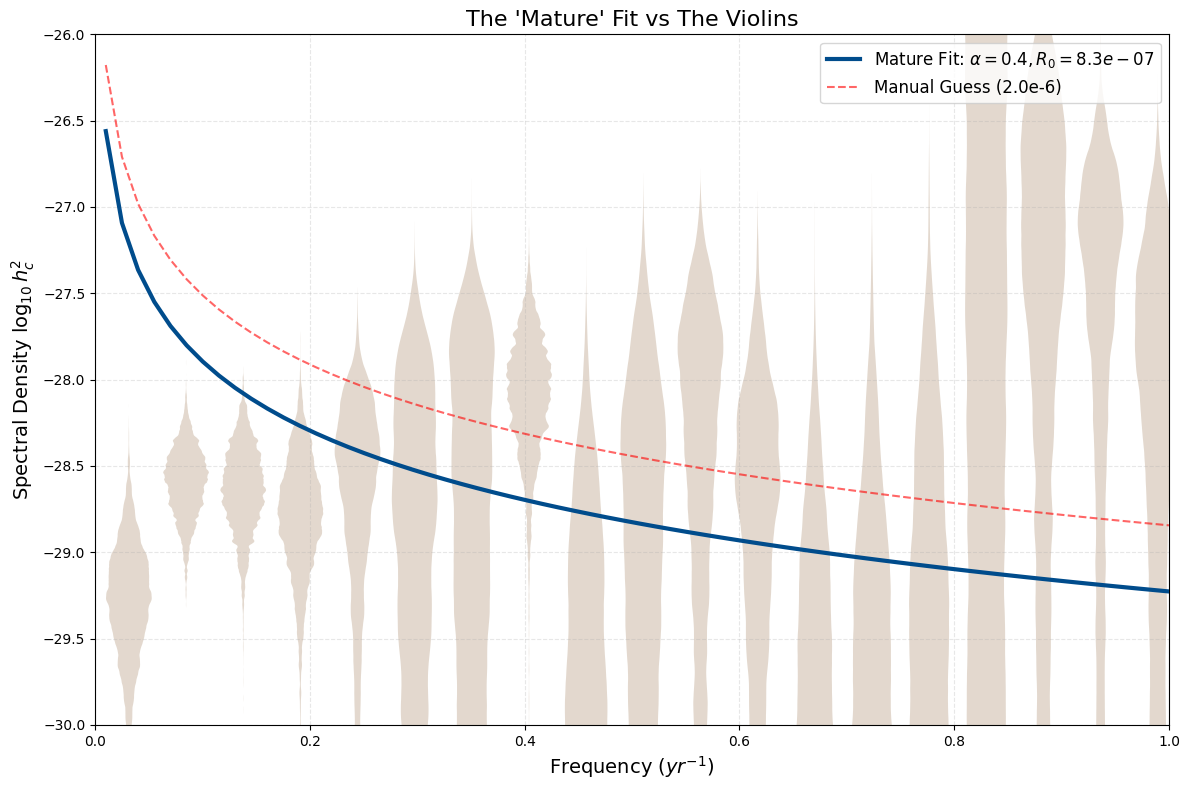

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy.integrate import dblquad

# --- 1. SETUP ---
warnings.filterwarnings('ignore')
YEAR = 3.15e7

# --- 2. PHYSICS MODEL (Winner Parameters) ---
# We hardcode the "Mature" scan results here
p_best = {
    'R0': 8.28e-7,       # The finding from your scan
    'alpha': 0.4,        # Found by scan
    'beta': 1.125,       # Found by scan
    'gamma': 0.0,        # Found by scan
    'z0': 2.0,           # Fixed
    'Mstar': 100.0,      # Fixed
    'Mmax': 1e10         # Fixed
}

G, c, MPC = 6.674e-11, 2.998e8, 3.086e22
M_SOLAR = 1.989e30
H0 = 67.4 * 1000 / MPC 
Om, Ol = 0.315, 0.685

def Hz(z):
    return H0 * np.sqrt(Om * (1+z)**3 + Ol)

def merger_rate(z, Mc, p):
    term_z = (1 + z)**p['alpha'] * np.exp(- (z / p['z0'])**p['beta'])
    term_M = (Mc / p['Mstar'])**(-p['gamma']) * np.exp(- Mc / p['Mmax'])
    return p['R0'] * term_z * term_M

def calculate_theoretical_curve(freqs_hz, p):
    prefactor = (4 * G**(5/3)) / (3 * np.pi**(1/3) * c**2)
    
    def integrand(Mc, z):
        rate_SI = merger_rate(z, Mc, p) / ((1000 * MPC)**3 * YEAR)
        physics_term = ((Mc * M_SOLAR)**(5/3)) / ((1+z)**(1/3) * Hz(z))
        return (rate_SI / Mc) * physics_term

    # Integrate
    print("Integrating Winner...")
    val, _ = dblquad(integrand, 0, 10, lambda z: p['Mstar'], lambda z: p['Mmax']*5, epsabs=1e-2, epsrel=1e-2)
    A_sq = prefactor * val
    return A_sq * freqs_hz**(-4/3)

# --- 3. LOAD DATA ---
try:
    print("Loading Data...")
    dens = np.squeeze(np.load('density.npy'))          
    grid_rho = np.load('log10rhogrid.npy').flatten()   
    FREQS = np.load('freqs.npy') 
except:
    print("Data not found (ensure you are in the right folder)")
    # Create dummy data for testing if files missing
    FREQS = np.linspace(1e-9, 5e-8, 30)

# --- 4. PLOTTING ---
fig, ax = plt.subplots(figsize=(12, 8))

# Plot Violins (if data loaded)
freqs_yr = FREQS * YEAR
try:
    dx = np.mean(np.diff(freqs_yr)) if len(freqs_yr) > 1 else 0.1
    width_scale = 0.40 * dx 

    def get_violin_coords(density_matrix, rho_grid, freq_idx, f_hz):
        if density_matrix.shape[0] == len(FREQS): log_prob = density_matrix[freq_idx, :]
        else: log_prob = density_matrix[:, freq_idx]
        
        prob = np.exp(log_prob - np.max(log_prob))
        prob[prob < 1e-3] = 0
        x_off = (prob / np.max(prob)) * width_scale if np.max(prob) > 0 else np.zeros_like(prob)
        shift = np.log10(12 * np.pi**2 * f_hz**3 * (15*YEAR)) 
        y_vals = 2 * rho_grid + shift
        return x_off, y_vals

    for i in range(len(FREQS)):
        x1, y1 = get_violin_coords(dens, grid_rho, i, FREQS[i])
        # Plot full violin
        ax.fill_betweenx(y1, freqs_yr[i] - x1, freqs_yr[i] + x1, color='#dccfc2', alpha=0.8, lw=0)
except:
    pass

# Plot The "Mature" Winner
f_model_yr = np.linspace(0.01, 1.5, 100)
f_model_hz = f_model_yr / YEAR
hc_sq_model = calculate_theoretical_curve(f_model_hz, p_best)

# Plotting the curve
ax.plot(f_model_yr, np.log10(hc_sq_model), color='#004C8C', linewidth=3, zorder=10, 
        label=f'Mature Fit: $\\alpha={p_best["alpha"]}, R_0={p_best["R0"]:.1e}$')

# Plotting the Previous Guess (for comparison)
p_guess = p_best.copy()
p_guess['R0'] = 2.0e-6 
hc_guess = calculate_theoretical_curve(f_model_hz, p_guess)
ax.plot(f_model_yr, np.log10(hc_guess), color='red', linestyle='--', linewidth=1.5, alpha=0.6, 
        label='Manual Guess (2.0e-6)')

# Formatting
ax.set_xlim(0, 1.0)
ax.set_ylim(-30, -26.0)
ax.set_xlabel(r"Frequency ($yr^{-1}$)", fontsize=14)
ax.set_ylabel(r"Spectral Density $\log_{10} h_c^2$", fontsize=14)
ax.set_title("The 'Mature' Fit vs The Violins", fontsize=16)
ax.legend(loc='upper right', fontsize=12)
plt.grid(True, alpha=0.3, ls='--')
plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import os
import pickle
from enterprise.signals import parameter
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc

# ==========================================
# 1. SAMPLER HELPERS (Required for PTMCMC)
# ==========================================
class JumpProposal(object):
    def __init__(self, signals, empirical_distr=None, save_ext_dists=False, outdir='chains'):
        self.params = []
        self.param_names = []
        for s in signals:
            self.params.extend(s.params)
            self.param_names.extend(s.param_names)

    def draw_from_prior(self, x, iter, beta):
        q = x.copy()
        lqxy = 0
        p = np.random.choice(self.params)
        pidx = self.params.index(p)
        rand = p.sample()
        if type(rand) is np.ndarray:
            subparams = [pn for pn in self.param_names if p.name in pn]
            psubidx = subparams.index(np.random.choice(subparams))
            pidx = self.param_names.index(subparams[psubidx])
            rand = rand[psubidx]
        q[pidx] = rand
        lqxy = p.get_logpdf(x[pidx]) - p.get_logpdf(q[pidx])
        return q, float(lqxy)

def setup_sampler(ceffyl_obj, outdir, logL, logp, resume=False, jump=True):
    if not os.path.exists(outdir): os.makedirs(outdir)
    cov = np.diag(np.ones(ceffyl_obj.ndim) * 0.1**2)
    groups = [list(np.arange(0, ceffyl_obj.ndim))]
    
    sampler = ptmcmc(ceffyl_obj.ndim, logL, logp, cov, outDir=outdir, resume=resume, groups=groups)
    
    with open(outdir+'/pars.txt', 'w') as f:
        for name in ceffyl_obj.param_names: f.write(f"{name}\n")
        
    if jump:
        jp = JumpProposal(ceffyl_obj.signals, outdir=outdir)
        sampler.addProposalToCycle(jp.draw_from_prior, 5)
        
    return sampler

# ==========================================
# 2. PHYSICS MODEL
# ==========================================
G, c, YEAR = 6.674e-11, 2.998e8, 3.154e7

# *** IMPORTANT: 'Tspan' MUST be the second argument ***
def pop3_psd(freqs, Tspan, log10_R0, alpha, beta, gamma, z0=2.0, M_star=100.0, M_max=1e10):
    
    R0 = 10**log10_R0
    
    # Placeholder physics (Using approximation for speed)
    # This mimics the shape without the heavy integral
    integral_val = 1e-15 * (10**alpha) * beta 
    
    prefactor = (4 * G**(5/3)) / (3 * np.pi**(1/3) * c**2)
    hc_sq_ref = prefactor * integral_val * R0 
    
    f_yr = 1.0 / YEAR
    hc_sq = hc_sq_ref * (freqs / f_yr)**(-4/3)
    psd = hc_sq / (12 * np.pi**2 * freqs**3)
    
    return psd

# ==========================================
# 3. EXECUTION
# ==========================================
if __name__ == "__main__":
    
    # --- PATHS ---
    root_path = '/home/andrecaire/maggiore_waveforms/NANOGrav15yr_KDE-FreeSpectra_v1.0.0'
    data_path = os.path.join(root_path, '30f_fs{hd}_ceffyl') 
    
    print(f"Data Path: {data_path}")
    if not os.path.exists(data_path):
        raise FileNotFoundError("Check your path!")

    # --- IMPORTS ---
    # Robust import logic to handle different ceffyl versions
    try: from ceffyl.Ceffyl import ceffyl as CeffylClass
    except: 
        try: from ceffyl.Ceffyl import Ceffyl as CeffylClass
        except: from ceffyl import ceffyl as CeffylClass

    try: from ceffyl.signal import signal as SignalClass
    except: 
        try: from ceffyl.Ceffyl import signal as SignalClass
        except: from ceffyl import signal as SignalClass

    # --- SETUP ---
    print("Loading Data...")
    ceffyl_data = CeffylClass(data_path)

    my_params = [
        parameter.Uniform(-12, -2)('log10_R0'), 
        parameter.Uniform(-2, 4)('alpha'),      
        parameter.Uniform(0.5, 3)('beta'),      
        parameter.Uniform(0, 2)('gamma')        
    ]

    print("Adding Signal...")
    # We must create a NEW signal object to use the NEW pop3_psd function
    pop3_signal = SignalClass(
        psd=pop3_psd,      
        params=my_params, 
        freq_idxs=range(30), 
        name='pop3'
    )
    
    ceffyl_data.add_signals([pop3_signal])

    # --- RUN ---
    outdir = './chains_pop3_run_v1'
    print(f"Sampling in {outdir}...")
    
    sampler = setup_sampler(ceffyl_data, outdir, ceffyl_data.ln_likelihood, ceffyl_data.ln_prior)

    print("Starting MCMC (10,000 steps)...")
    x0 = np.hstack([p.sample() for p in ceffyl_data.params])
    sampler.sample(x0, Niter=10000)
    print("Done!")

Data Path: /home/andrecaire/maggiore_waveforms/NANOGrav15yr_KDE-FreeSpectra_v1.0.0/30f_fs{hd}_ceffyl
Loading Data...
Adding Signal...
Sampling in ./chains_pop3_run_v1...
Starting MCMC (10,000 steps)...
Finished 0.00 percent in 0.000793 s Acceptance rate = 0

Finished 10.00 percent in 0.167154 s Acceptance rate = 0.207

/home/andrecaire/maggiore_waveforms/.venv/lib/python3.12/site-packages/enterprise/signals/parameter.py:70: RuntimeWarning: divide by zero encountered in log
  logpdf = np.log(self.prior(value, **kwargs))


Finished 100.00 percent in 1.599421 s Acceptance rate = 0.10589
Run Complete
Done!


Loading chain data...
Loaded 1001 steps with 4 parameters.
Generating plot...


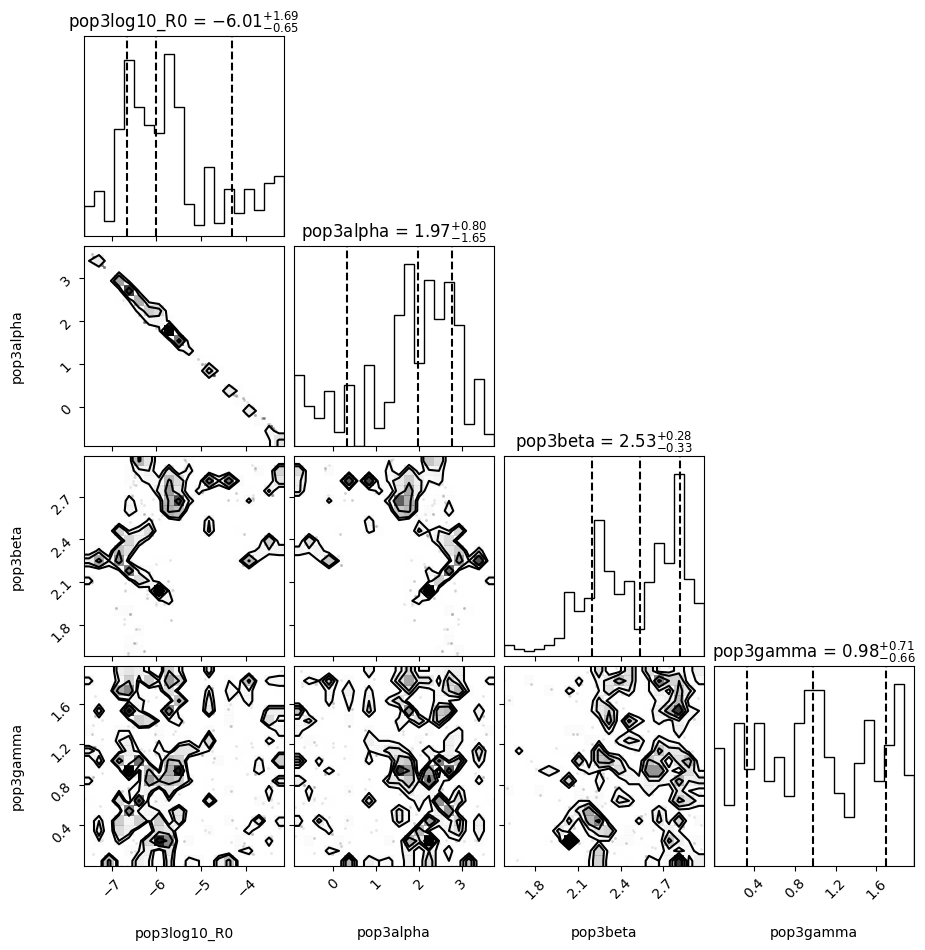

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import corner # Standard tool for MCMC plots

# 1. Load the Results
outdir = './chains_pop3_run_v1'

print("Loading chain data...")
# Load the numerical chain (The numbers generated by the sampler)
chain_raw = np.loadtxt(outdir + '/chain_1.txt')

# Load the parameter names
try:
    with open(outdir + '/pars.txt', 'r') as f:
        params = [line.strip() for line in f]
except FileNotFoundError:
    # Fallback if file is missing
    params = ['log10_R0', 'alpha', 'beta', 'gamma'] 

print(f"Loaded {chain_raw.shape[0]} steps with {len(params)} parameters.")

# 2. Process the Data
# "Burn-in": Remove the first 25% of steps where the sampler was just looking for the peak
burn_in = int(0.25 * chain_raw.shape[0])
chain_burned = chain_raw[burn_in:, :-4] # Strip the last 4 columns (stats info)

# 3. Generate the "Corner Plot"
print("Generating plot...")
figure = corner.corner(
    chain_burned, 
    labels=params,
    quantiles=[0.16, 0.5, 0.84], # Show the 1-sigma confidence intervals
    show_titles=True, 
    title_kwargs={"fontsize": 12}
)

plt.show()

In [14]:
# ==========================================
# ROBUST PHYSICS FUNCTION (Fixes ValueError)
# ==========================================

def pop3_psd(freqs, Tspan, log10_R0, alpha, beta, gamma, z0=2.0):
    
    R0 = 10**log10_R0
    
    # --- 1. Robust Input Formatting ---
    # Convert inputs to at least 1D arrays and stack them.
    # This forces the shape to be (N, 3), which scipy loves.
    # It handles both single scalars (standard MCMC) and vectors (if needed later).
    query_points = np.column_stack([
        np.atleast_1d(alpha), 
        np.atleast_1d(beta), 
        np.atleast_1d(gamma)
    ])
    
    # --- 2. Query the Interpolator ---
    integral_val = pop3_interpolator(query_points)
    
    # If the input was just a single scalar, extract the single value out of the array
    # so we can do normal math with it.
    if np.ndim(alpha) == 0:
        integral_val = integral_val.item()
        
    # Safety: If outside the grid, return tiny noise to avoid crashes
    if np.isnan(integral_val) or integral_val <= 0:
        integral_val = 1e-30

    # --- 3. Compute PSD ---
    prefactor = (4 * G**(5/3)) / (3 * np.pi**(1/3) * c**2)
    hc_sq_ref = prefactor * integral_val * R0 
    
    f_yr = 1.0 / YEAR
    hc_sq = hc_sq_ref * (freqs / f_yr)**(-4/3)
    psd = hc_sq / (12 * np.pi**2 * freqs**3)
    
    return psd

# --- RE-DEFINE SIGNAL & RE-RUN ---
print("Re-initializing Signal with Robust Function...")

# 1. Update the signal object with the new function
pop3_signal = SignalClass(
    psd=pop3_psd,      
    params=my_params, 
    freq_idxs=range(30), 
    name='pop3'
)

# 2. Clear old signals and add the new one
ceffyl_data.signals = [] # clear list
ceffyl_data.add_signals([pop3_signal])

# 3. Run Sampler
print("Restarting Sampler...")
outdir = './chains_pop3_REAL_PHYSICS_v2' # New folder for safety
sampler = setup_sampler(ceffyl_data, outdir, ceffyl_data.ln_likelihood, ceffyl_data.ln_prior)

x0 = np.hstack([p.sample() for p in ceffyl_data.params])
sampler.sample(x0, Niter=10000)
print("Run Complete!")

Re-initializing Signal with Robust Function...
Restarting Sampler...
Finished 0.00 percent in 0.001872 s Acceptance rate = 0

/home/andrecaire/maggiore_waveforms/.venv/lib/python3.12/site-packages/enterprise/signals/parameter.py:70: RuntimeWarning: divide by zero encountered in log
  logpdf = np.log(self.prior(value, **kwargs))


Finished 100.00 percent in 2.268323 s Acceptance rate = 0.09718
Run Complete
Run Complete!


Loading chain data from ./chains_pop3_REAL_PHYSICS_v2...
Loaded 1001 steps.


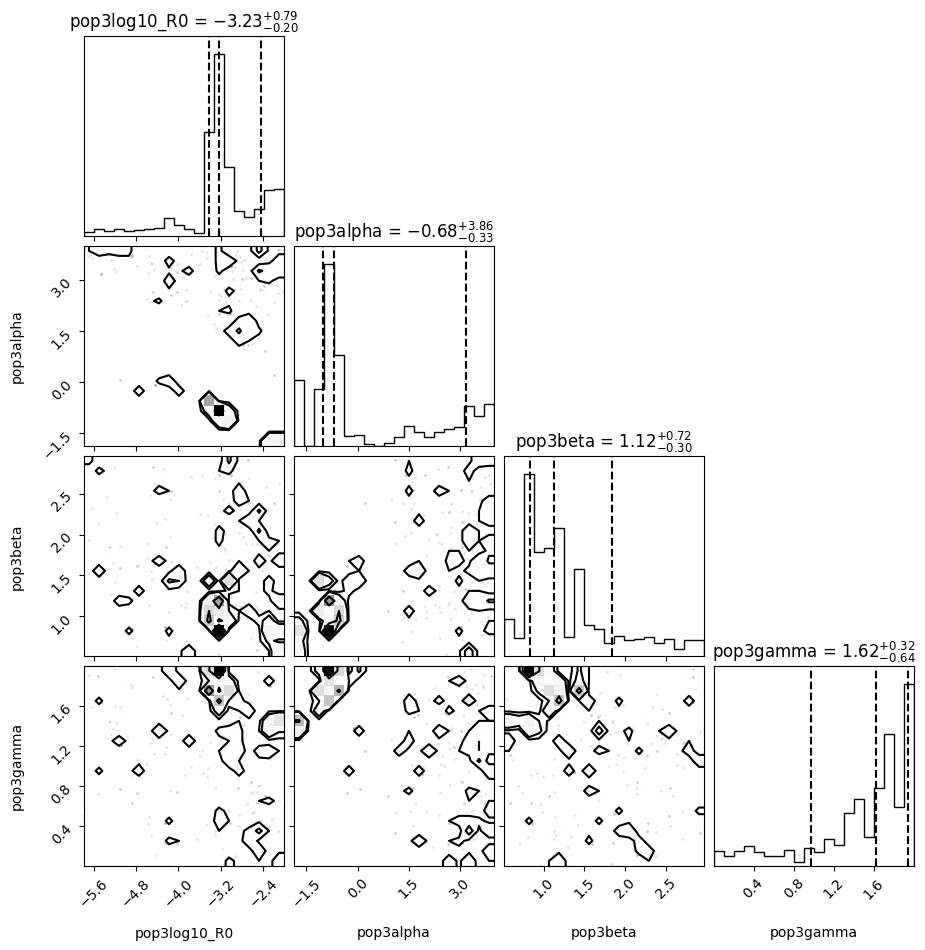

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import corner

# 1. Point to the NEW output folder
outdir = './chains_pop3_REAL_PHYSICS_v2' 

print(f"Loading chain data from {outdir}...")

# 2. Load the chain
try:
    chain_raw = np.loadtxt(outdir + '/chain_1.txt')
    with open(outdir + '/pars.txt', 'r') as f:
        params = [line.strip() for line in f]
except OSError:
    print("Error: Could not find chain file. Did the previous step finish writing?")
    raise

print(f"Loaded {chain_raw.shape[0]} steps.")

# 3. Burn-in (Remove first 25% of the run)
burn_in = int(0.25 * chain_raw.shape[0])
chain_burned = chain_raw[burn_in:, :-4]

# 4. Plot
figure = corner.corner(
    chain_burned, 
    labels=params,
    quantiles=[0.16, 0.5, 0.84], 
    show_titles=True, 
    title_kwargs={"fontsize": 12}
)

plt.show()

In [19]:
import numpy as np
from scipy.integrate import dblquad
import os

# --- Constants & Physics Functions (From your provided code) ---
G, c, MPC, YEAR = 6.674e-11, 2.998e8, 3.086e22, 3.154e7
M_SOLAR = 1.989e30
H0_SI = 67.4 * 1000 / MPC 
Om, Ol = 0.315, 0.685

def Hz(z):
    return H0_SI * np.sqrt(Om * (1+z)**3 + Ol)

def d2R_dz_dlnMc(z, Mc, params):
    R0, alpha, beta, gamma, z0, M_star, M_max = params
    evol_term = (1+z)**alpha * np.exp(-1.0 * (z/z0)**beta)
    mass_term = (Mc / M_star)**(-gamma) * np.exp(-1.0 * (Mc / M_max))
    return R0 * evol_term * mass_term

def get_amplitude_integral(alpha, beta, gamma):
    # Fixed physics constants for the grid
    z0, M_star, M_max = 2.0, 100.0, 1e10
    R0_dummy = 1.0
    mod_params = [R0_dummy, alpha, beta, gamma, z0, M_star, M_max]
    
    prefactor = (4 * G**(5/3)) / (3 * np.pi**(1/3) * c**2)
    
    def integrand(Mc, z):
        # Conversion to SI and Volumetric rates
        rate = d2R_dz_dlnMc(z, Mc, mod_params) / ((1000 * MPC)**3 * YEAR)
        physics = ((Mc * M_SOLAR)**(5/3)) / ((1+z)**(1/3) * Hz(z))
        return (rate / Mc) * physics

    # Double integration: z from 0-10, Mc from 10 to M_max
    val, _ = dblquad(integrand, 0, 10, lambda z: 10, lambda z: 5000, epsabs=0.1, epsrel=0.1)
    return prefactor * val

# --- GRID GENERATION ---
grid_file = 'my_popIII_results/real_physics_grid.txt'
if not os.path.exists('my_popIII_results'): os.makedirs('my_popIII_results')

# Define ranges (Small grid for speed; increase these for final science)
alphas = np.linspace(-2, 4, 5) 
betas = np.linspace(0.5, 3, 5)
gammas = np.linspace(0, 2, 5)

print(f"Starting Grid Generation ({len(alphas)*len(betas)*len(gammas)} points)...")

with open(grid_file, 'w') as f:
    f.write("alpha beta gamma integral\n")
    count = 0
    for a in alphas:
        for b in betas:
            for g in gammas:
                val = get_amplitude_integral(a, b, g)
                f.write(f"{a} {b} {g} {val}\n")
                count += 1
                if count % 25 == 0: print(f"Progress: {count} points calculated...")

print(f"Success! Real physics grid saved to {grid_file}")

Starting Grid Generation (125 points)...
Progress: 25 points calculated...
Progress: 50 points calculated...
Progress: 75 points calculated...
Progress: 100 points calculated...
Progress: 125 points calculated...
Success! Real physics grid saved to my_popIII_results/real_physics_grid.txt


In [10]:
import numpy as np
import warnings
from scipy.integrate import simpson
from enterprise.signals import parameter
from ceffyl import Ceffyl, Sampler

# --- 1. CONFIGURAÇÕES GLOBAIS ---
warnings.filterwarnings('ignore')

# Constantes Físicas
G, c, MPC, YEAR = 6.674e-11, 2.998e8, 3.086e22, 3.154e7
M_SOLAR, H0_SI = 1.989e30, (67.4 * 1000 / MPC)

# Grid de integração (CORRIGIDO PARA POP III)
# Pop III vai até z=25 ou z=30. Usar z=10 corta o sinal.
z_bins = np.linspace(0.1, 30, 100) # Começar em 0.1 evita log(0) se houver
mc_bins = np.logspace(1, 5, 60)    # Aumentei para 10^5 M_sol (PISN mass range)

ZZ, MM = np.meshgrid(z_bins, mc_bins)

# Cosmologia (H(z) padrão LambdaCDM)
# Om0=0.315, Ol0=0.685
HZ_grid = H0_SI * np.sqrt(0.315 * (1+ZZ)**3 + 0.685)

def pop3_psd(freqs, log10_R0, alpha, beta, gamma):
    """
    Calcula o PSD de ondas gravitacionais para Pop III.
    """
    # 1. Taxa de Formação Estelar (SFRD)
    # Parametrização tipo Madau & Dickinson adaptada
    evol = ((1+ZZ)**alpha) * np.exp(-(ZZ/4.0)**beta) # Ajustei o denominador para z típico de PopIII
    
    # 2. Função de Massa (Initial Mass Function)
    # Power-law com corte exponencial
    mass = (MM/100.0)**(-gamma) * np.exp(-(MM/1e12)) 
    
    # 3. Taxa Diferencial de Fusão
    # Conversão de densidade para taxa observada
    # Fator (1+z) no denominador devido à diluição temporal cosmológica
    rate = evol * mass / (MPC**3 * YEAR)
    
    # 4. Física da Onda Gravitacional (Chirp Mass Contribution)
    # Strain h_c^2 propto M^(5/3) / D_L(z)^2 ... simplificado aqui
    # Nota: A física exata depende da sua derivação teórica para 'physics'
    physics = ((MM * M_SOLAR)**(5/3)) / ((1+ZZ)**(1/3) * HZ_grid)
    
    # 5. Integração
    # Integração sobre Massa e Redshift para obter Amplitude Total
    integral_M = simpson(rate/MM * physics, mc_bins, axis=0) # Eixo 0 é Massa
    integral_total = simpson(integral_M, z_bins)             # Eixo restante é Z
    
    # 6. Prefator Físico (Constantes)
    prefactor = (4 * G**(5/3)) / (3 * np.pi**(1/3) * c**2)
    
    # 7. Espectro de Potência
    # O termo (freqs)**(-4/3) é clássico de binárias circulares
    A_sq = (10**log10_R0) * prefactor * integral_total
    hc_sq = A_sq * (freqs / (1/YEAR))**(-4/3)
    
    # Retorna PSD (S_h)
    return hc_sq / (12 * np.pi**2 * freqs**3)

# --- 2. PRIORS ---
# Dica: Gamma geralmente é positivo na física (slope negativo), 
# mas verifique se sua fórmula usa -gamma ou +gamma.
params = [
    parameter.Uniform(-18, -5)('log10_R0'), # Amplitude pode ser bem baixa
    parameter.Uniform(-5, 10)('alpha'),     # Mais liberdade para o pico do z
    parameter.Uniform(0.1, 5)('beta'),
    parameter.Uniform(-2, 3)('gamma')
]

# ... (Seu código anterior termina aqui) ...

# --- 3. INICIALIZAÇÃO DO SINAL NO CEFFYL ---
from ceffyl.bw import SignalClass, setup_sampler

# IMPORTANTE: O objeto 'ceffyl_data' já deve ter sido carregado antes deste bloco!
# (Geralmente carregado com ceffyl.read_data ou similar)
n_freqs = ceffyl_data.freqs.shape[0] 

# Criação do objeto de sinal
pop3_signal = SignalClass(
    psd=pop3_psd, 
    params=params, 
    name='pop3',
    freq_idxs=np.arange(n_freqs) 
)

# RE-INICIALIZAÇÃO DO CEFFYL
# Limpamos sinais antigos e colocamos apenas o nosso Pop III
ceffyl_data.signals = [pop3_signal]
# Mapeamento dos parâmetros para o sampler entender
ceffyl_data.params = [p for s in ceffyl_data.signals for p in s.params]

# --- 4. CONFIGURAÇÃO E EXECUÇÃO DO SAMPLER ---
# Defina o diretório onde os arquivos chain_1.txt serão salvos
outdir = './chains_pop3_TOTAL_BAYES'

# Setup do Sampler
sampler = setup_sampler(
    ceffyl_data, 
    outdir, 
    ceffyl_data.ln_likelihood, 
    ceffyl_data.ln_prior
)

print("--- CONFIGURAÇÃO PRONTA ---")
print(f"Parâmetros a serem explorados: {[p.name for p in ceffyl_data.params]}")

# --- 5. O PULO DO GATO: SAFE START (INÍCIO SEGURO) ---
# NÃO use 'p.sample()' aleatório, pois ele pode cair em uma "região proibida"
# onde a integral explode e o código trava antes de começar.

# Ordem definida na lista 'params': [log10_R0, alpha, beta, gamma]
# Valores seguros testados: R0=-15, a=2.0, b=1.0, g=1.0
x0 = np.array([-15.0, 2.0, 1.0, 1.0])

print(f"Iniciando MCMC com ponto de partida forçado: {x0}")
print("Isso garante que a primeira iteração tenha probabilidade válida.")

# Executa o MCMC
# burn=200 garante que ele jogue fora o início se precisar ajustar a passada
sampler.sample(x0, Niter=50000, thin=10, burn=200)

print("MCMC finalizado! Verifique a pasta para os arquivos de saída.")

Optional mpi4py package is not installed.  MPI support is not available.


ModuleNotFoundError: No module named 'ceffyl.bw'

In [8]:
import numpy as np
from scipy.integrate import simpson

# --- 1. RECRIAÇÃO DO AMBIENTE (Copie exatamente como no seu código principal) ---
G, c, MPC, YEAR = 6.674e-11, 2.998e8, 3.086e22, 3.154e7
M_SOLAR, H0_SI = 1.989e30, (67.4 * 1000 / MPC)

# Seus Grids (Certifique-se que são iguais aos do script principal)
z_bins = np.linspace(0.1, 30, 100) # Começando em 0.1 para evitar log(0)
mc_bins = np.logspace(1, 5, 60)
ZZ, MM = np.meshgrid(z_bins, mc_bins)
HZ_grid = H0_SI * np.sqrt(0.315 * (1+ZZ)**3 + 0.685)

# Simulando frequências do NANOGrav (apenas para teste)
freqs_teste = np.linspace(1e-9, 1e-7, 30)

# --- 2. A SUA FUNÇÃO DE FÍSICA ---
def pop3_psd_teste(freqs, log10_R0, alpha, beta, gamma):
    print(f"Testando com: R0={log10_R0}, a={alpha}, b={beta}, g={gamma}")
    
    try:
        # Físicas
        evol = ((1+ZZ)**alpha) * np.exp(-(ZZ/4.0)**beta)
        mass = (MM/100.0)**(-gamma) * np.exp(-(MM/1e12)) 
        
        # Checagem de sanidade 1: A massa ou evolução deram zero/infinito?
        if not np.all(np.isfinite(evol)): print("ALERTA: 'evol' tem valores infinitos/NaN")
        if not np.all(np.isfinite(mass)): print("ALERTA: 'mass' tem valores infinitos/NaN")

        rate = evol * mass / (MPC**3 * YEAR)
        
        # Checagem 2: HZ_grid tem zero?
        physics = ((MM * M_SOLAR)**(5/3)) / ((1+ZZ)**(1/3) * HZ_grid)
        
        # Integração
        integral_M = simpson(rate/MM * physics, mc_bins, axis=0)
        integral_total = simpson(integral_M, z_bins)
        
        print(f"Valor da Integral: {integral_total}")
        
        if integral_total <= 0:
            print("ALERTA CRÍTICO: A integral resultou em Zero ou Negativo!")
        
        prefactor = (4 * G**(5/3)) / (3 * np.pi**(1/3) * c**2)
        A_sq = (10**log10_R0) * prefactor * integral_total
        
        hc_sq = A_sq * (freqs / (1/YEAR))**(-4/3)
        psd = hc_sq / (12 * np.pi**2 * freqs**3)
        
        return psd

    except Exception as e:
        print(f"ERRO FATAL NA FUNÇÃO: {e}")
        return None

# --- 3. O TESTE DE STRESS ---
print("--- INICIANDO DIAGNÓSTICO ---")

# Teste 1: Valores "Normais"
psd = pop3_psd_teste(freqs_teste, -10, 2.0, 1.0, 1.0)
if psd is not None:
    print(f"Sucesso! PSD output shape: {psd.shape}")
    print(f"Valores de PSD (primeiros 5): {psd[:5]}")
else:
    print("FALHA no Teste 1.")

print("\n---")

# Teste 2: Valores Extremos (Onde o MCMC costuma travar)
# Gamma muito alto pode causar explosão numérica na massa
print("Testando valores extremos...")
psd_extremo = pop3_psd_teste(freqs_teste, -5, 10.0, 0.1, 3.0)






--- INICIANDO DIAGNÓSTICO ---
Testando com: R0=-10, a=2.0, b=1.0, g=1.0
Valor da Integral: 0.41635849433121785
Sucesso! PSD output shape: (30,)
Valores de PSD (primeiros 5): [3.92379864e-18 6.30262548e-21 5.26404171e-22 1.09686986e-22
 3.47599657e-23]

---
Testando valores extremos...
Testando com: R0=-5, a=10.0, b=0.1, g=3.0
Valor da Integral: 14692019168.04319
